# 00 - Data download and inspection

Pulls SPY (headline) and TLT (out-of-domain check) from Yahoo Finance via `yfinance`,
caches to `data/raw/`, and slices the train/test windows defined in section 5 of the
proposal. The pre-training window uses **^GSPC** (1990-01-01 -> 1992-12-31) since SPY
itself launched 1993-01-22 and cannot fill the pre-1994 calibration window. ^GSPC over
1990-1992 spans the 1990 recession and the 1991-92 recovery (~750 trading days), and
the window closes strictly before SPY's first trading day so no test-time information
leaks into the prior.

All plotting in this notebook is delegated to `project.plots`; no inline matplotlib.


In [1]:
import sys
from pathlib import Path

# Make the in-tree package importable without `pip install -e .`.
NB_ROOT = Path.cwd().resolve()
SRC = NB_ROOT.parent / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd

from project import data, plots
from project.utils import RAW_DIR, set_seed, ensure_dirs

ensure_dirs()
rng = set_seed()


## Download (or load from cache)

`download_prices` writes parquet to `data/raw/<symbol>_<start>_<end>.parquet`
and reads it back on subsequent runs. We report cache hit / miss honestly so a
fresh checkout shows that the network was hit, and reruns show that it wasn't.


In [2]:
def cache_status(symbol: str, start: str, end: str) -> str:
    safe = symbol.lstrip("^")
    path = RAW_DIR / f"{safe}_{start}_{end}.parquet"
    return "hit " if path.exists() else "miss"

loads = [
    ("SPY",   data.SPY_START,      data.SPY_END,      data.load_spy),
    ("TLT",   data.SPY_START,      data.SPY_END,      data.load_tlt),
    ("^GSPC", data.PRETRAIN_START, data.PRETRAIN_END, data.load_pretrain),
]
frames = {}
for sym, start, end, loader in loads:
    status = cache_status(sym, start, end)
    frames[sym] = loader()
    df = frames[sym]
    print(f"{sym:<6} cache={status}  rows={len(df):>5}  {df.index.min().date()} -> {df.index.max().date()}")

spy, tlt, gspc = frames["SPY"], frames["TLT"], frames["^GSPC"]
spy.tail()


SPY    cache=hit   rows= 8369  1993-01-29 -> 2026-04-29
TLT    cache=hit   rows= 5976  2002-07-30 -> 2026-04-29
^GSPC  cache=hit   rows=  759  1990-01-02 -> 1992-12-30


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-04-23,708.450012,712.359985,702.280029,709.500000,56174000
2026-04-24,713.940002,714.469971,709.010010,710.750000,45182000
2026-04-27,715.169983,715.630005,712.299988,713.169983,33135900
2026-04-28,711.690002,712.880005,709.250000,711.820007,43117400
2026-04-29,711.580017,712.200012,708.369995,711.000000,41859200


## Window splits

`split_windows` slices SPY into `train` (1994-2019) and `test` (2020-2026).
The pre-training window is *not* a slice of SPY -- it lives on a different
ticker (^GSPC) and is loaded separately via `data.load_pretrain()`.


In [3]:
splits = data.split_windows(spy)

print(f"{'pretrain (^GSPC)':>20}: {len(gspc):>5} days  ({gspc.index.min().date()} -> {gspc.index.max().date()})")
for name, df in splits.items():
    print(f"{name + ' (SPY)':>20}: {len(df):>5} days  ({df.index.min().date()} -> {df.index.max().date()})")


    pretrain (^GSPC):   759 days  (1990-01-02 -> 1992-12-30)
         train (SPY):  6546 days  (1994-01-03 -> 2019-12-31)
          test (SPY):  1589 days  (2020-01-02 -> 2026-04-29)


## SPY adjusted close with split shading

Log-scale price over SPY's full history. Translucent shading marks the train
(1994-2019) and test (2020-2026) windows. The pre-training window lives on
^GSPC and is plotted separately below.


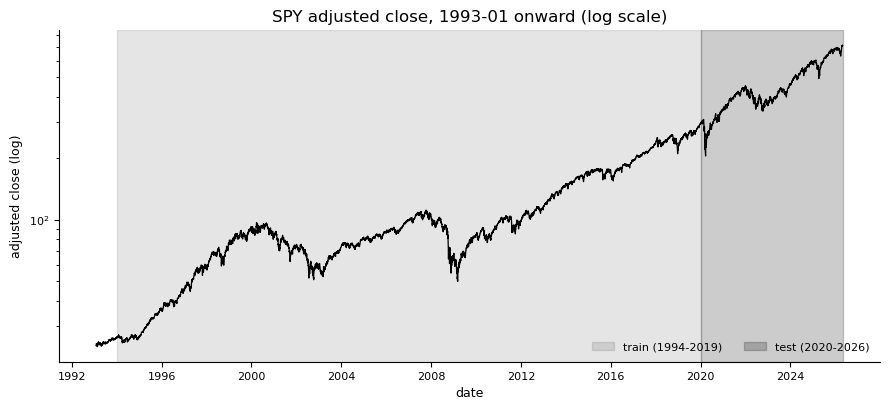

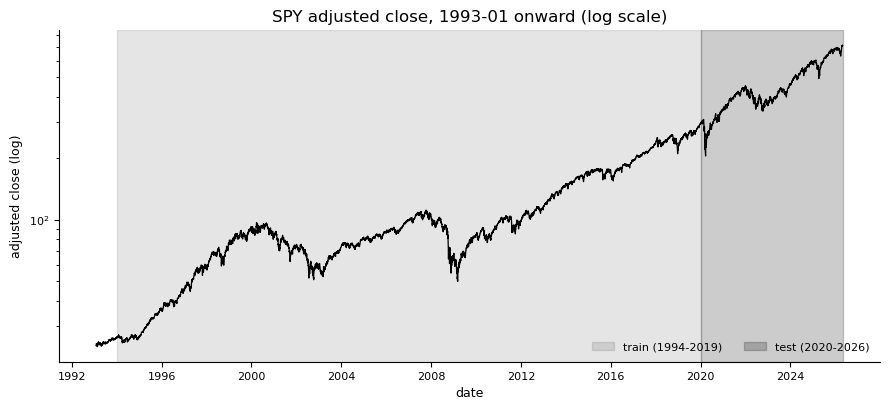

In [4]:
fig, ax = plots.plot_price_series(
    spy,
    splits={
        "train (1994-2019)": (data.TRAIN_START, data.TRAIN_END),
        "test (2020-2026)":  (data.TEST_START,  data.TEST_END),
    },
    log_scale=True,
)
ax.set_title("SPY adjusted close, 1993-01 onward (log scale)")
fig


## Pre-training ticker: ^GSPC, 1990-1992

Plotted on its own axes because the index level is not directly comparable to
SPY's per-share price. The variance of the daily returns is what we calibrate
against; absolute level is irrelevant.


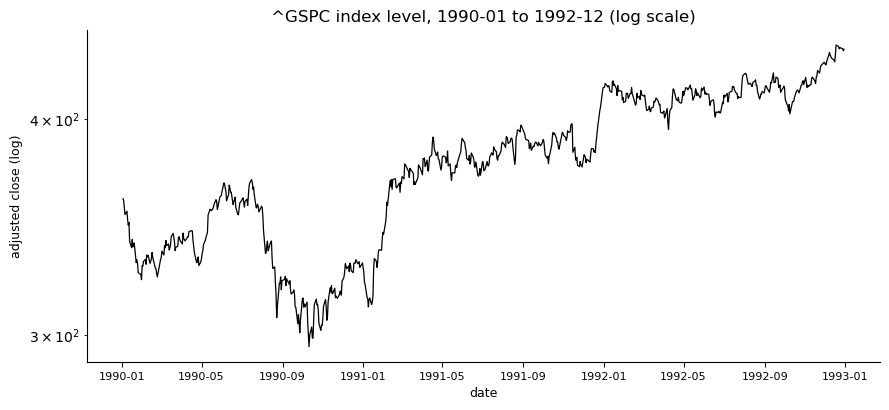

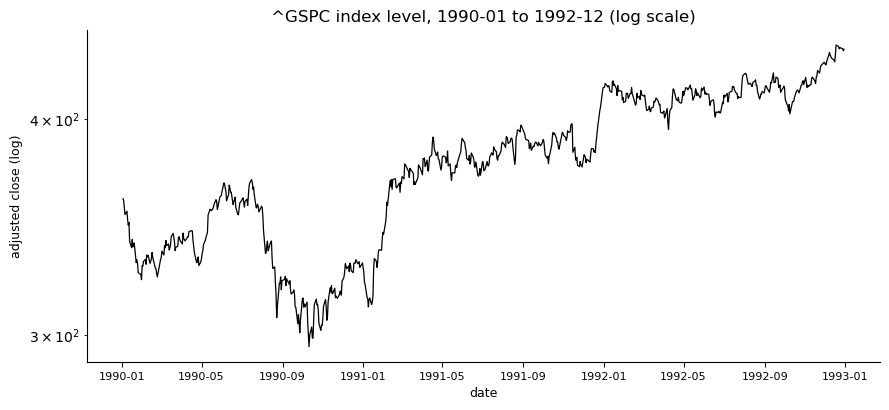

In [5]:
fig, ax = plots.plot_price_series(gspc, log_scale=True)
ax.set_title("^GSPC index level, 1990-01 to 1992-12 (log scale)")
fig


## Daily log-return distribution: SPY training window

The Bayesian-vs-Student-t question on the proposal hinges on the tail behaviour
of the *MC return* `y_t`, not the daily return `r_t`. But the daily moments
establish a baseline: heavy daily tails will only get heavier under the rolling
MC sum, so a visibly fat-tailed `r_t` is sufficient (not necessary) to justify
the Student-t scale-mixture variant of the sampler.

Below we print summary moments for all three windows, then overlay a fitted
Normal and a fitted Student-t on the SPY training-window histogram.


In [6]:
def moments(r, name):
    print(f"{name:<22}  n={len(r):>5}  mean={r.mean():+.5f}  std={r.std():.5f}  "
          f"skew={r.skew():+.3f}  kurt+3={r.kurt()+3:.2f}")

r_pre   = np.log(gspc["Close"]).diff().dropna()
r_train = np.log(splits['train']["Close"]).diff().dropna()
r_test  = np.log(splits['test']["Close"]).diff().dropna()

moments(r_pre,   "pretrain (^GSPC)")
moments(r_train, "train    (SPY)")
moments(r_test,  "test     (SPY)")


pretrain (^GSPC)        n=  758  mean=+0.00026  std=0.00853  skew=-0.031  kurt+3=4.67
train    (SPY)          n= 6545  mean=+0.00037  std=0.01157  skew=-0.145  kurt+3=13.14
test     (SPY)          n= 1588  mean=+0.00055  std=0.01292  skew=-0.551  kurt+3=16.55


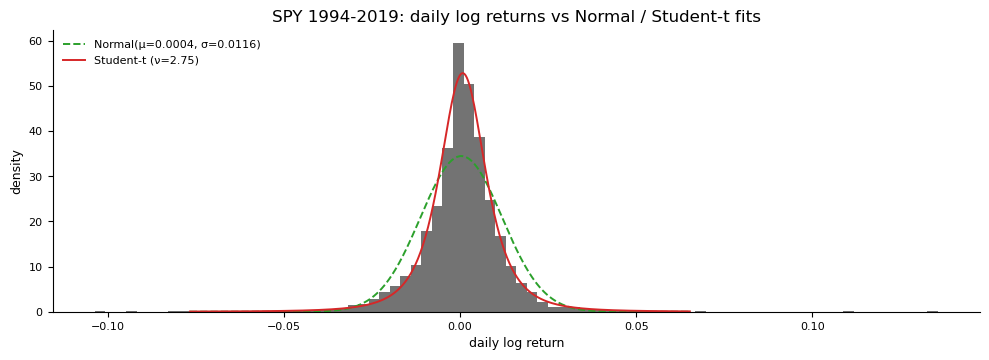

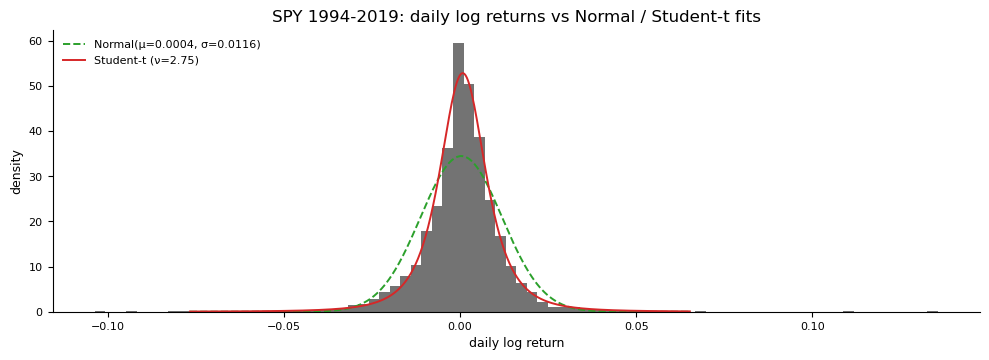

In [7]:
fig, ax = plots.plot_returns_distribution(
    r_train,
    show_normal_overlay=True,
    show_t_overlay=True,
)
ax.set_title("SPY 1994-2019: daily log returns vs Normal / Student-t fits")
fig


The Student-t fit's degrees of freedom estimate is what justifies
`sampler_t.py` existing: a finite, low estimate (well under 30) means the
Normal envelope visibly fails in the tails, and the scale-mixture variant
is not gold-plating.


## Transaction-cost model `c_t = c_0 + lambda * sigma_t^(20)`

The cost model is the only feedback channel that punishes turnover. Plotting
`c_t` over the full sample makes the regime-dependent component concrete:
during 2008 and 2020 the volatility-scaled term dominates the 5-bp floor by an
order of magnitude, which is exactly why a constant-cost backtest would be
misleading on this dataset.


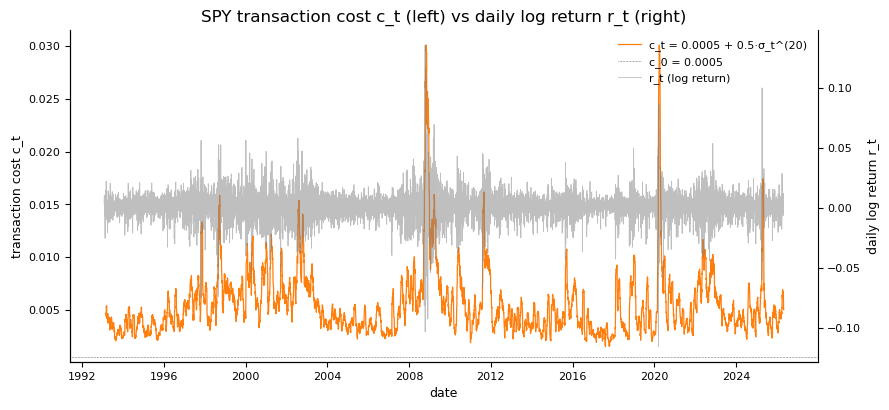

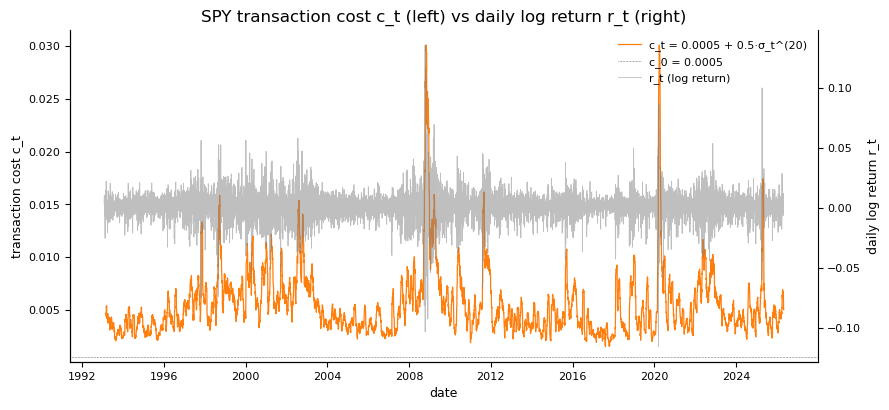

In [8]:
fig, ax = plots.plot_cost_model(spy)
ax.set_title("SPY transaction cost c_t (left) vs daily log return r_t (right)")
fig


## Sanity checks


In [9]:
# No NaNs in adjusted close
assert spy["Close"].notna().all(),  "SPY has NaN closes"
assert tlt["Close"].notna().all(),  "TLT has NaN closes"
assert gspc["Close"].notna().all(), "^GSPC has NaN closes"

# Pretrain window is sealed strictly before SPY's first trading day -- NO LEAKAGE
assert gspc.index.max() < pd.Timestamp(data.SPY_START), \
    "pretrain window must close strictly before SPY's first trading day"

# Train and test windows are disjoint and ordered
assert splits["train"].index.max() < splits["test"].index.min()

# Pretrain ticker covers (approximately) the proposal's 1990-1992 window
assert gspc.index.min().year == 1990
assert gspc.index.max().year == 1992

# Test window covers the COVID crash and 2022 bear market
assert splits["test"].loc["2020-03"].shape[0] > 0
assert splits["test"].loc["2022-10"].shape[0] > 0

print("OK")


OK
